In [1]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile
from czifile import CziFile

import math
import matplotlib.colors as mcolors

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
# this shows how many delta7 are there in each subtype

delta7_naming = pd.read_csv('neuprint_delta7_names.csv')
#delta7_naming = delta7_naming.drop(columns=["notes"])
delta7_naming['instance'] = delta7_naming['instance'].str.replace(r'^Delta7\(PB15\)_', '', regex=True)
delta7_naming.sort_values('instance', inplace=True)
delta7_naming.reset_index(drop=True, inplace=True)
subtype_summary = delta7_naming.groupby("instance").size().reset_index(name="count")
subtype_summary

,instance,count
0,L1L9R8_R,5
1,L2R7_R,5
2,L3R6_R,4
3,L4R5_R,5
4,L4R6_R,2
5,L5R4_L,5
6,L6R3_L,5
7,L6R4_L,2
8,L7R2_L,3
9,L7R3_L,1


In [ ]:
fly1 = '/Users/fisherguest/Documents/sansa images/08142025/SC-0814-fly1.czi'
fly2 = '/Users/fisherguest/Documents/sansa images/08142025/SC-0814-fly2.czi'
#fly_100 = '/Users/fisherguest/Documents/sansa images/08152025/SC-0815-fly?.czi'

fly3_left = '/Users/fisherguest/Documents/sansa images/08202025/SC-0820-fly3-left.czi'
fly3_right = '/Users/fisherguest/Documents/sansa images/08202025/SC-0820-fly3-right.czi'

fly4 = '/Users/fisherguest/Documents/sansa images/08242025/SC-0824-fly4.czi'
fly5_down = '/Users/fisherguest/Documents/sansa images/08242025/SC-0824-fly5-down.czi'
fly5_up = '/Users/fisherguest/Documents/sansa images/08242025/SC-0824-fly5-up.czi'
fly6 = '/Users/fisherguest/Documents/sansa images/08242025/SC-0824-fly6.czi'
fly7 = '/Users/fisherguest/Documents/sansa images/08242025/SC-0824-fly7.czi'

fly8 = '/Users/fisherguest/Documents/sansa images/08292025/SC-0829-fly8.czi'

fly9 = '/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly9.czi'
fly10 = '/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly10.czi'
fly11_left = '/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly11-left.czi'
fly11_right = '/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly11-right.czi'

fly12_left = '/Users/fisherguest/Documents/sansa images/09072025/SC-0907-fly11-left.czi'
fly12_right = '/Users/fisherguest/Documents/sansa images/09072025/SC-0907-fly11-right.czi'
fly13 = '/Users/fisherguest/Documents/sansa images/09072025/SC-0907-fly13.czi'
fly14_left = '/Users/fisherguest/Documents/sansa images/09072025/SC-0907-fly14-left.czi'
fly14_right = '/Users/fisherguest/Documents/sansa images/09072025/SC-0907-fly14-right.czi'



In [4]:
# import image:
img = AICSImage(fly8)

# Get the data in (C, Z, Y, X)
# C: Channels (e.g., the different lasers/fluorophores); Z: Z-stacks (slices in depth); Y and X: The spatial dimensions (height and width)
# i don't have S or T.
data = img.get_image_data("CZYX", S=0, T=0)

# checked using "previous TQ method": (633 is the first channel date[0]), 568 is first (no actually second) channel, 488 is second (no actually third) channel.
red_channel   = data[1]
green_channel = data[2]
blue_channel = data[0]

In [ ]:
# open image in napari to draw labels:
viewer = napari.Viewer()

# Add the red channel
viewer.add_image(
    red_channel, 
    name='568 Channel',
    colormap='red',
    contrast_limits=(0, 1000), # adjust this if needed
    blending='additive'
)
# Add the green channel
viewer.add_image(
    green_channel, 
    name='488 Channel',
    colormap='green',
    contrast_limits=(0, 800), # adjust this if needed
    blending='additive'
)

# Add the blue channel
viewer.add_image(
    blue_channel, 
    name='633 Channel',
    colormap='blue',
    #contrast_limits=(50, 800), # adjust this if needed
    blending='additive'
)

napari.run()

2025-09-08 11:10:08.545 python[96604:118798055] +[IMKClient subclass]: chose IMKClient_Legacy
2025-09-08 11:10:08.545 python[96604:118798055] +[IMKInputSession subclass]: chose IMKInputSession_Legacy
2025-09-08 12:23:58.959 python[96604:118798055] The class 'NSSavePanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


In [7]:
# File paths
label_file = '/Users/fisherguest/Documents/sansa images/08292025/roi/fly8.tif'


# Load the label mask (the TIFF file you saved from napari)
label_mask = tf.imread(label_file)
# for the label tif file obtained in previous TQ method, need the below precessing:
#squeezed_mask = np.squeeze(label_mask) # so change from shape: (1, 2, Z, Y, X) to (2, Z, Y, X)
#squeezed_mask_green = squeezed_mask[1] # so only extract the green (second) channel.
print("Label mask shape:", label_mask.shape)
print("Green channel shape:", green_channel.shape)
print("Red channel shape:", red_channel.shape)


# Check that the dimensions match (e.g., both are 3D)
if green_channel.shape != label_mask.shape:
    raise ValueError("The dimensions of the green channel and the label mask do not match. "
                     "Please verify that your label mask corresponds to the correct z, y, and x dimensions.")

Label mask shape: (155, 1839, 1839)
Green channel shape: (155, 1839, 1839)
Red channel shape: (155, 1839, 1839)


In [42]:
label_file_checking = '/Users/fisherguest/Documents/sansa images/08292025/roi/fly8-bg.tif'
label_mask_checking = tf.imread(label_file_checking)

In [8]:
# check which z stack I drew the label on.
sums = label_mask.sum(axis=(1,2))
painted_slices = np.where(sums > 0)[0]
print("You painted on slice(s):", painted_slices)

You painted on slice(s): [93]


In [9]:
z_ranges = [
(0, 1),
(0, 78),
(8, 95),
(9, 97),
(25, 115),
(53, 133),
(65, 151),
(94, 154),
(100, 154),
(68, 154),
(67, 140),
(66, 134),
(62, 135),
(69, 136),
(36, 134),
(10, 116),
(5, 89),
(2, 66),
]

In [ ]:
# variable input cell
red_threshold_lower = 71
green_threshold_lower = 112

In [39]:
# --- compute stats with proper red-first, green-subset logic ---

n_glom = int(label_mask.max())

mean_red    = np.zeros(n_glom, dtype=float)
mean_green  = np.zeros(n_glom, dtype=float)
total_red   = np.zeros(n_glom, dtype=float)
total_green = np.zeros(n_glom, dtype=float)
n_red_px    = np.zeros(n_glom, dtype=int)
n_green_px  = np.zeros(n_glom, dtype=int)

# Optional: basic validation of z_ranges length
if len(z_ranges) != n_glom:
    raise ValueError(f"z_ranges has length {len(z_ranges)} but label_mask has {n_glom} labels.")

for i in range(1, n_glom + 1):
    # 1) find the slice you painted on:
    zs, ys, xs = np.where(label_mask == i)          # THIS COMMENT WILL SOLVE MANY POTENTIAL QUESTIONS: label_mask size is in this format: (Z, Y, X)
    if zs.size == 0:
        # No pixels for this label; keep NaNs/zeros
        continue
    z_draw = zs[0]                                  # AICSImage makes the image format in this way! (i don't know why not in X->Y->Z).  z_draw = z layer that you draw labels on (a number).

    # 2) 2D ROI on that slice:
    roi2d = (label_mask[z_draw] == i)               # roi2d = a T/F information on that one z plane you have label 1 draw onto.
                                                    # label_mask[z_draw] gives 2d array (Y, X): entries are the integer labels (background:0, ROIs:1-18) (the entries are numbers because that's what the label_mask tiff is like).
                                                    # label_mask[z_draw] == i: give each pixel True of False based on if it's has label 1. So now on this 2D sheet, only the pixels you draw (eg.) label 1 on has a T value.

    # 3) build the Z-range selector:
    z0, z1 = z_ranges[i - 1]                        # z0=a lowest z layer that the current label reaches, while z1=the highesr z laye the current label goes to.
    Z, Y, X = label_mask.shape                      # label_mask is the full X * full Y * full Z that your current image (eg. fly1) has. Z, Y, X are the length of the image (number of pixels).
    mask_z = (np.arange(Z) >= z0) & (np.arange(Z) <= z1)    # NOT USED IN BELOW PARTS!!!
                                                            # np.arange(Z): generates the array [0, 1, 2, …, Z−1] (yes, the entries are numbers, not bool) --> this mask_z is only a T/F filter for the first dimension (which is Z).
                                                            # np.arange(Z) >= z0: generates the array [False, F, ...T, T, ... F]
                                                            # () & (): generates the array with True only for indices between z0 and z1.
                                                            
    # 4) 3D ROI over the Z-range by broadcasting roi2d across selected Z
    # This is equivalent to your earlier construction, but a bit more explicit:
    roi = np.zeros_like(label_mask, dtype=bool)             # roi = 3D array of F as the only entries, the size = the label_mask (or the size of your image).
    roi[z0:z1+1, :, :] = roi2d[None, :, :]                  # roi[z0:z1+1, :, :] = a 3D array of bool, but only with the z slices in the range of this label 1. ":" means "no slicing and include all".
                                                            # roi2d[None, :, :]  = the previous 2D array of T/F now added one more dimension (Z). chatgpt said the new Z dimension is "a new axis".
                                                            # roi[z0:z1+1, :, :] = roi2d[None, :, :]: broadcasts (1, Y, X) → (z0:z1+1, Y, X).
                                                            # NOW, roi is the 3D array of T/F which basically copy and paste roi2d to all the z slices in wherez0:z1+1. (on each z slice: T in where the label is drawn on, and definitely F outside the labels.)
                                                                # yes, weird grammar that i have never heard before (called "broadcast").

    # Slice channels to the Z-range (faster & clearer)
    red_sub   = red_channel[z0:z1+1]                        # shape (Zsel, Y, X): red_channel[z0:z1+1]: takes only the z-stacks from the original image (red channel only) that are within the *current label's* z-stack range. No changes were made to the red and green channels. 
                                                            # red_sub = entries are fluorescence values, not T/F!!!                                   
    green_sub = green_channel[z0:z1+1]                      # again, only select out the correct z stacks, haven't picked the inner pixels yet!
    roi_sub   = roi[z0:z1+1]                                # roi[z0:z1+1]: only get the z0:z1+1 z slices in that 3D T/F array you just built.
                                                            # roi_sub = 3D!

    # ---- Thresholding logic ----
    # A) Pixels inside ROI (any Z in the chosen range)
    mask_roi = roi_sub
    # B) Finalized red pixels (apply red threshold INSIDE ROI)
    mask_red = mask_roi & (red_sub > red_threshold_lower)           # mask_red = a 3D array of T/F where T is in pixels only both conditions are met.
    # C) Green subset pixels (subset of red pixels that also pass green threshold)
    mask_green = mask_red & (green_sub > green_threshold_lower)     # mask_green = a 3D array of T/F where T is in pixels only both conditions are met. NOTE: mask_green is built on mask_red!!!!!!!!!

    # ---- Extract values ----
    red_vals   = red_sub[mask_red]                                  # applies the True/False mask and keeps only the voxels where the mask is T to red_sub, which is the origianl image with only some z slices included. red_vals is no longer a 3D array, but a 1D array, with entries being the signal value from the T pixels.
    green_vals = green_sub[mask_green]

    # ---- Save stats (NaN if empty) ----
    n_red_px[i - 1]   = red_vals.size
    n_green_px[i - 1] = green_vals.size

    mean_red[i - 1]    = red_vals.mean()   if red_vals.size   else np.nan
    total_red[i - 1]   = red_vals.sum()    if red_vals.size   else np.nan
    mean_green[i - 1]  = green_vals.mean() if green_vals.size else np.nan
    total_green[i - 1] = green_vals.sum()  if green_vals.size else np.nan

# Optional: quick sanity check that subset property holds
if not np.all(n_green_px <= n_red_px):
    print("Warning: some ROIs have more green pixels than red pixels — check thresholds and masks.")

# Assemble results
df_means = pd.DataFrame(
    {
        'mean_red':    mean_red,
        'mean_green':  mean_green,
        'total_red':   total_red,
        'total_green': total_green,
        'n_red_px':    n_red_px,
        'n_green_px':  n_green_px,
    },
    index=np.arange(1, n_glom + 1)
)
df_means

,mean_red,mean_green,total_red,total_green,n_red_px,n_green_px
1,114.624277,182.603774,7.932000e+04,67746.0,692,371
2,380.913145,176.259460,2.588297e+08,39077956.0,679498,221707
3,408.037236,195.063021,4.147372e+08,65475634.0,1016420,335664
4,430.351418,193.657175,4.728667e+08,74223179.0,1098792,383271
5,390.734224,190.627063,3.933326e+08,61862104.0,1006650,324519
6,342.496416,171.340427,4.692129e+08,51209884.0,1369979,298878
7,282.780733,170.883479,2.708154e+08,20830867.0,957687,121901
8,721.957298,233.067564,1.684338e+09,129797657.0,2333016,556910
9,299.502837,185.827322,1.984036e+08,12901991.0,662443,69430
10,324.613380,206.642877,4.512957e+08,39863684.0,1390256,192911


In [15]:
df_means.to_csv(f"fly8.csv")

In [ ]:
'''df_means = pd.DataFrame(
    [mean_red, mean_green, total_red, total_green],
    index=['mean_red', 'mean_green', 'total_red', 'total_green']
)

df_means.T.to_csv(f"fly1.csv")
'''

In [ ]:
# this cell is for when one brain is split into 2 images, and need to have the values combined into one csv...

# build the dataframe
data = {
    "mean_red": [
        95.689903, 244.708255, 85.982069, 87.822602, 93.642687, 106.009298,
        128.30713, 119.484986, 97.095008, 234.183041, 105.323247, 106.027822,
        126.8595, 141.105013, 153.156412, 205.923968, 146.704492, 239.888989
    ],
    "mean_green": [
        22.3198, 24.493158, 17.833971, 13.558714, 14.336447, 17.595527,
        20.401557, 19.864207, 14.987217, 26.001336, 21.642499, 23.489537,
        24.551414, 26.666706, 29.18899, 35.560629, 36.782444, 40.622732
    ],
    "total_red": [
        120096323, 613873783, 95379737, 84603465, 107275845, 135048107,
        208664859, 154102773, 100665483, 662037565, 128691526, 123137319,
        205863156, 268482061, 176626254, 311569965, 278433829, 535220205
    ],
    "total_green": [
        23466471, 68059125, 19783188, 13061719, 16423647, 22415417,
        33178889, 25619365, 15538342, 73506012, 26444363, 27279997,
        39841176, 50739034, 33661940, 53804440, 69810246, 97960443
    ]
}

flycurrent_df = pd.DataFrame(data)

# save it as fly3.csv in current directory
flycurrent_df.to_csv("fly1.csv", index=True)

In [72]:
data = {
    "mean_red": [
        226.7161137, 375.7397814, 176.5323650, 165.5426320, 169.2362450, 191.5620210,
        210.8443620, 220.5365570, 187.1936270, 345.3469510, 197.8328800, 207.4211950,
        224.5444610, 242.5400610, 252.8775250, 302.3122050, 240.7296710, 368.6674023
    ],
    "mean_green": [
        101.6884096, 107.5509364,  98.6538800,  97.0893170,  88.0221670,  97.4160020,
         95.8757110,  93.7258140,  95.5768700, 107.0935160,  95.8146630, 100.4373330,
        103.6605700, 101.3665210, 104.3321640, 103.9395440,  95.0105710, 105.2957397
    ],
    "total_red": [
         73592504, 536670633,  43300388,  40649490,  57169019,  82043715,
        150510615, 103299544,  54947694, 588856612,  76056455,  73170108,
        142618067, 199964336, 137904735, 270485985, 209345503, 451499226
    ],
    "total_green": [
        607995,  8932643,   223747,    55438,   107211,   415187,
       1196433,   782798,   208262, 11961489,   514908,   789337,
       1932544,  2591131,  2676746,  6263293,  6731594, 18191945
    ],
    "n_red_px": [
        324602, 1428304, 245283, 245553, 337806, 428288,
        713847, 468401, 293534, 1705116, 384448, 352761,
        635144, 824459, 545342, 894724, 869629, 1224679
    ],
    "n_green_px": [
        5979,  83055,  2268,   571,  1218,  4262,
       12479,   8352,  2179, 111692,  5374,  7859,
       18643,  25562,  25656,  60259,  70851, 172770
    ],
}

df = pd.DataFrame(data, index=range(1, 19))
#df.index.name = "ROI"

# ensure integer columns are saved as ints (optional but tidy)
#int_cols = ["total_red", "total_green", "n_red_px", "n_green_px"]
#df[int_cols] = df[int_cols].astype("int64")

# save CSV
out_path = "fly5.csv"  # change path/name as needed
df.to_csv(out_path, index=True, float_format="%.6f")

# going to let the codes to decide the thresholds

Global Z range (clipped): 0..154  (from raw 0..154, Z=155)


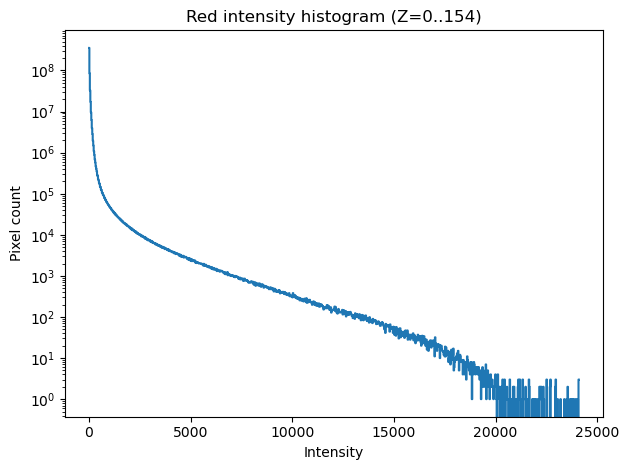

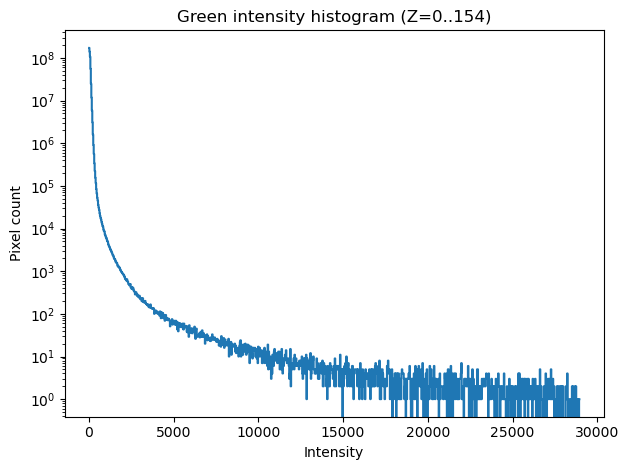

In [ ]:
# ---------- 1) pick global Z range from your z_ranges ----------
# Example z_ranges (already defined by you):
# z_ranges = [(0,1),(0,78),(8,95), ... ,(2,66)]

# gather all 36 numbers
all_z = [int(z) for pair in z_ranges for z in pair]
z0_raw, z1_raw = min(all_z), max(all_z)

# clip to valid bounds
Z = red_channel.shape[0]
z0 = max(0, min(z0_raw, Z - 1))
z1 = max(0, min(z1_raw, Z - 1))
if z1 < z0:
    z0, z1 = z1, z0

print(f"Global Z range (clipped): {z0}..{z1}  (from raw {z0_raw}..{z1_raw}, Z={Z})")

# ---------- 2) slice both channels to that Z window ----------
red_sel   = red_channel[z0 : z1 + 1]
green_sel = green_channel[z0 : z1 + 1]

# ---------- 3) histogram helper ----------
def make_hist(arr, bins=1024, exclude_zero=False, use_dtype_range=False):
    a = arr.ravel()                                                                                             # .ravel() gets all the pixels' value and put in a 1D array
    if exclude_zero:
        a = a[a != 0]
    if a.size == 0:
        raise ValueError("No pixels to histogram after selection.")

    if use_dtype_range and np.issubdtype(arr.dtype, np.integer):
        lo, hi = 0, np.iinfo(arr.dtype).max
    else:
        lo, hi = float(a.min()), float(a.max())

    counts, edges = np.histogram(a, bins=bins, range=(lo, hi))                                                  # edges: the cut points on the intensity axis that partition values into bins.
    centers = (edges[:-1] + edges[1:]) / 2.0
    return counts, edges, centers

# choose your prefs here:
BINS = 1024
EXCLUDE_ZERO = False     # set True to drop zeros
USE_DTYPE_RANGE = False  # set True for full uint16 span, if desired

# ---------- 4) compute & plot ----------
cr, er, xr = make_hist(red_sel,   bins=BINS, exclude_zero=EXCLUDE_ZERO, use_dtype_range=USE_DTYPE_RANGE)
cg, eg, xg = make_hist(green_sel, bins=BINS, exclude_zero=EXCLUDE_ZERO, use_dtype_range=USE_DTYPE_RANGE)

plt.figure()
plt.plot(xr, cr, drawstyle="steps-mid")
plt.yscale("log")
plt.xlabel("Intensity"); plt.ylabel("Pixel count")
plt.title(f"Red intensity histogram (Z={z0}..{z1})")
plt.tight_layout()

plt.figure()
plt.plot(xg, cg, drawstyle="steps-mid")
plt.yscale("log")
plt.xlabel("Intensity"); plt.ylabel("Pixel count")
plt.title(f"Green intensity histogram (Z={z0}..{z1})")
plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_intensity_histograms_with_percentile(
    red_channel,
    green_channel,
    z_ranges,
    q=0.05,                 # percentile as fraction (e.g., 0.05 = 5%)
    bins=1024,
    exclude_zero=False,     # True to ignore zeros in both percentile + histogram
    use_dtype_range=False   # True to force full integer dtype range for binning
):
    # ---- derive global Z window from z_ranges ----
    all_z = [int(z) for pair in z_ranges for z in pair]
    z0_raw, z1_raw = min(all_z), max(all_z)
    Z = int(red_channel.shape[0])
    z0 = max(0, min(int(z0_raw), Z - 1))
    z1 = max(0, min(int(z1_raw), Z - 1))
    if z1 < z0:
        z0, z1 = z1, z0
    print(f"Global Z range (clipped): {z0}..{z1} (from raw {z0_raw}..{z1_raw}, Z={Z})")

    # ---- select and flatten ----
    red_sel   = red_channel[z0 : z1 + 1].ravel()
    green_sel = green_channel[z0 : z1 + 1].ravel()
    if exclude_zero:
        red_sel   = red_sel[red_sel != 0]
        green_sel = green_sel[green_sel != 0]
    red_sel   = red_sel[np.isfinite(red_sel)]
    green_sel = green_sel[np.isfinite(green_sel)]
    if red_sel.size == 0 or green_sel.size == 0:
        raise ValueError("No pixels to analyze after selection (check Z range or filters).")

    # ---- percentile thresholds (compat with older NumPy) ----
    def qtile(a, qf):
        try:
            return float(np.quantile(a, qf, method="linear"))
        except TypeError:
            return float(np.quantile(a, qf, interpolation="linear"))

    thr_red   = qtile(red_sel, q)
    thr_green = qtile(green_sel, q)

    # actual fractions ≤ the threshold (ties make this ≥ q)
    frac_red   = float((red_sel   <= thr_red).mean())
    frac_green = float((green_sel <= thr_green).mean())
    print(f"Red   {q*100:.1f}th pct = {thr_red:.6g} | fraction ≤ line: {frac_red*100:.2f}%")
    print(f"Green {q*100:.1f}th pct = {thr_green:.6g} | fraction ≤ line: {frac_green*100:.2f}%")

    # ---- histograms ----
    def make_hist(a, dtype, bins, use_dtype_range):
        if use_dtype_range and np.issubdtype(dtype, np.integer):
            lo, hi = 0, np.iinfo(dtype).max
        else:
            lo, hi = float(a.min()), float(a.max())
        counts, edges = np.histogram(a, bins=bins, range=(lo, hi))
        centers = (edges[:-1] + edges[1:]) / 2.0
        return counts, edges, centers

    cr, er, xr = make_hist(red_sel,   red_channel.dtype,   bins, use_dtype_range)
    cg, eg, xg = make_hist(green_sel, green_channel.dtype, bins, use_dtype_range)

    # ---- plots with vertical percentile lines + shaded left region ----
    plt.figure()
    plt.plot(xr, cr, drawstyle="steps-mid")
    plt.axvline(thr_red, color="red", linestyle="--", linewidth=1.5,
                label=f"{q*100:.1f}th pct = {thr_red:.2f}")
    plt.fill_between(xr, cr, where=xr <= thr_red, step="mid", alpha=0.2)
    plt.yscale("log")
    plt.xlabel("Intensity"); plt.ylabel("Pixel count")
    plt.title(f"Red histogram (Z={z0}..{z1})")
    plt.legend(); plt.tight_layout()

    plt.figure()
    plt.plot(xg, cg, drawstyle="steps-mid")
    plt.axvline(thr_green, color="red", linestyle="--", linewidth=1.5,
                label=f"{q*100:.1f}th pct = {thr_green:.2f}")
    plt.fill_between(xg, cg, where=xg <= thr_green, step="mid", alpha=0.2)
    plt.yscale("log")
    plt.xlabel("Intensity"); plt.ylabel("Pixel count")
    plt.title(f"Green histogram (Z={z0}..{z1})")
    plt.legend(); plt.tight_layout()

    return {
        "z_range": (z0, z1),
        "q": q,
        "red":   {"threshold": thr_red,   "fraction_leq": frac_red,   "counts": cr, "edges": er},
        "green": {"threshold": thr_green, "fraction_leq": frac_green, "counts": cg, "edges": eg},
    }
#NOTE: The reason your “fraction ≤ line” is 51.74% and 50.82% (not exactly 50%) is because your data are integer intensities with many ties at the median value.
# When you count ≤ threshold, you include all pixels equal to the median, so the cumulative fraction usually jumps over 50%.

Global Z range (clipped): 0..154 (from raw 0..154, Z=155)
Red   50.0th pct = 12 | fraction ≤ line: 51.74%
Green 50.0th pct = 47 | fraction ≤ line: 50.82%


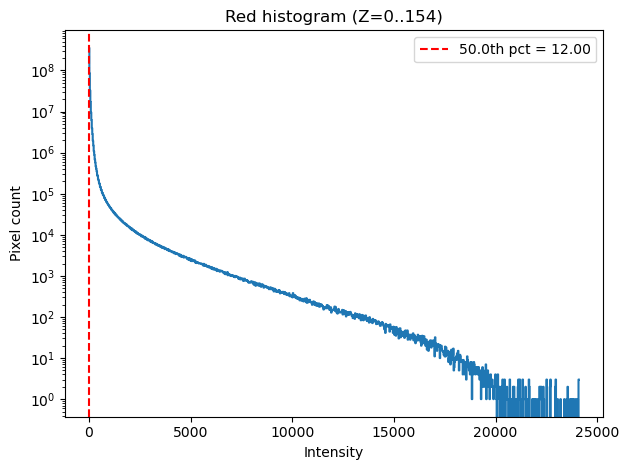

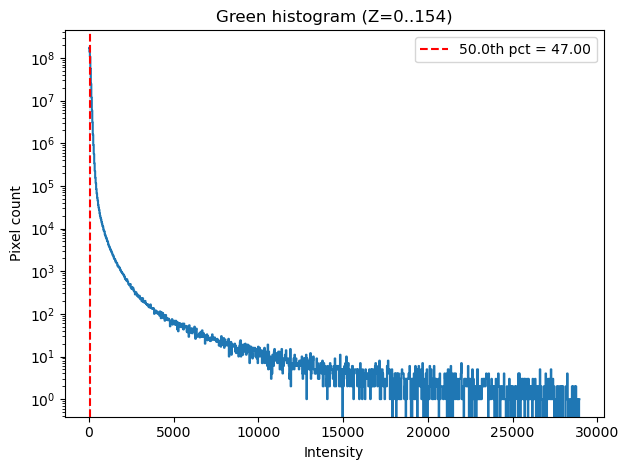

In [32]:
out10 = plot_intensity_histograms_with_percentile(
    red_channel, green_channel, z_ranges, q=0.50, exclude_zero=False, use_dtype_range=False
)

Global Z range (clipped): 0..154 (from raw 0..154, Z=155)
Red   90.0th pct = 71 | fraction ≤ line: 90.09%
Green 90.0th pct = 112 | fraction ≤ line: 90.24%


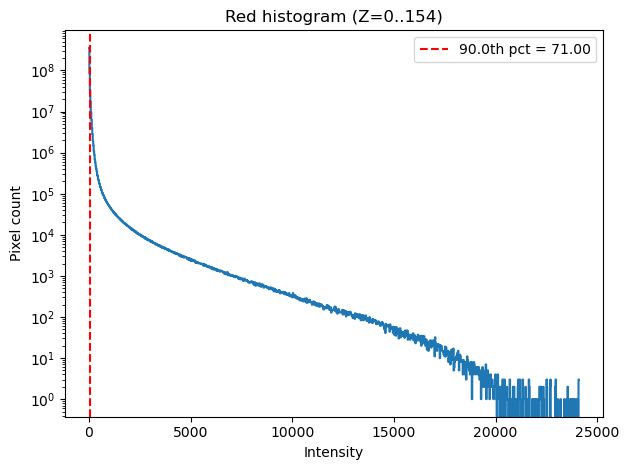

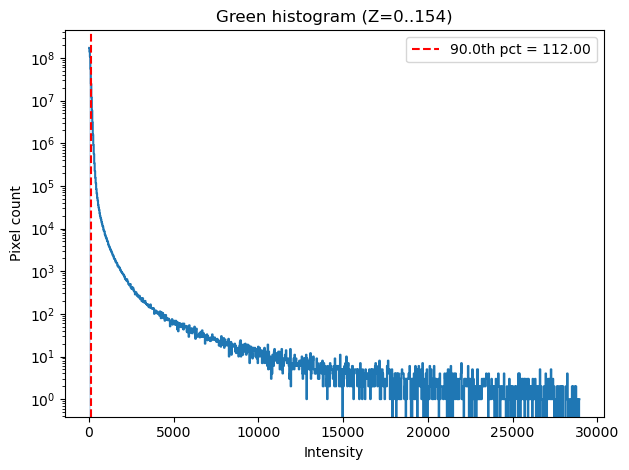

In [ ]:
out10 = plot_intensity_histograms_with_percentile(
    red_channel, green_channel, z_ranges, q=0.90, exclude_zero=False, use_dtype_range=False
)

# now only use the backgronud roi:

In [ ]:
def plot_roi_histograms_per_slice(
    red_channel,
    green_channel,
    label_mask_checking,   # 3D labels: 0=bg, 1..n; each ROI painted on one Z slice (sparse pixels)
    q=0.05,                # percentile as fraction, e.g. 0.05 = 5%
    bins=512,              # histogram bins
    exclude_zero=False,    # ignore zeros inside the ROI
    use_dtype_range=False, # fix x-axis to full integer dtype (e.g., uint16 0..65535)
    roi_ids=None           # which ROIs to plot; None -> all positive labels
):
    # Ensure labels are (Z, Y, X)
    lbl = np.asarray(label_mask_checking)
    if lbl.ndim > 3:
        lbl = np.squeeze(lbl)
    if lbl.ndim != 3:
        raise ValueError(f"label_mask_checking must be 3D (Z,Y,X); got shape {lbl.shape}")
    if lbl.shape != red_channel.shape or lbl.shape != green_channel.shape:
        raise ValueError(f"shape mismatch: labels {lbl.shape}, red {red_channel.shape}, green {green_channel.shape}")

    n_max = int(lbl.max())
    if n_max < 1:
        raise ValueError("label_mask_checking has no positive labels.")
    if roi_ids is None:
        roi_ids = range(1, n_max + 1)
    else:
        roi_ids = [int(r) for r in roi_ids if 1 <= int(r) <= n_max]

    # Percentile helper (NumPy version compatible)
    def qtile(a, qf):
        a = np.asarray(a)
        a = a[np.isfinite(a)]
        if a.size == 0:
            return np.nan
        try:
            return float(np.quantile(a, qf, method="linear"))
        except TypeError:
            return float(np.quantile(a, qf, interpolation="linear"))

    # Histogram helper
    def make_hist(a, dtype, bins, use_dtype_range):
        if a.size == 0:
            # safe degenerate histogram
            return np.array([0]), np.array([0, 1]), np.array([0.5])
        if use_dtype_range and np.issubdtype(dtype, np.integer):
            lo, hi = 0, np.iinfo(dtype).max
        else:
            lo, hi = float(a.min()), float(a.max())
            if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
                lo, hi = 0.0, 1.0
        counts, edges = np.histogram(a, bins=bins, range=(lo, hi))
        centers = (edges[:-1] + edges[1:]) / 2.0
        return counts, edges, centers

    summary = {}

    for i in roi_ids:
        # Find which Z slice this ROI was drawn on (expects exactly one Z; uses the first found)
        z_hits = np.where(lbl == i)[0]
        if z_hits.size == 0:
            print(f"ROI {i}: no painted pixels; skipping.")
            continue
        z_draw = int(z_hits[0])

        # 2D mask for ROI i on that exact slice (ONLY pixels inside the painted ROI)
        mask2d = (lbl[z_draw] == i)
        if not mask2d.any():
            print(f"ROI {i}: empty mask at z={z_draw}; skipping.")
            continue

        # STRICT ROI-only sampling via explicit coordinates
        y_ix, x_ix = np.where(mask2d)
        red_vals   = red_channel[z_draw,  y_ix, x_ix]
        green_vals = green_channel[z_draw, y_ix, x_ix]

        if exclude_zero:
            red_vals   = red_vals[red_vals != 0]
            green_vals = green_vals[green_vals != 0]

        # Percentiles & fractions for this ROI
        thr_red   = qtile(red_vals, q)
        thr_green = qtile(green_vals, q)
        frac_red   = float((red_vals   <= thr_red).mean()) if red_vals.size   else np.nan
        frac_green = float((green_vals <= thr_green).mean()) if green_vals.size else np.nan

        print(f"ROI {i} @ z={z_draw}")
        print(f"Red   {q*100:.1f}th pct = {thr_red:.6g} | fraction ≤ line: {frac_red*100:.2f}%")
        print(f"Green {q*100:.1f}th pct = {thr_green:.6g} | fraction ≤ line: {frac_green*100:.2f}%")

        # Histograms (ROI-only)
        cr, er, xr = make_hist(red_vals,   red_channel.dtype,   bins, use_dtype_range)
        cg, eg, xg = make_hist(green_vals, green_channel.dtype, bins, use_dtype_range)

        # Plots
        plt.figure()
        plt.plot(xr, cr, drawstyle="steps-mid")
        plt.axvline(thr_red, linestyle="--", linewidth=1.5,
                    label=f"{q*100:.1f}th = {thr_red:.2f}")
        plt.fill_between(xr, cr, where=xr <= thr_red, step="mid", alpha=0.2)
        plt.yscale("log")
        plt.xlabel("Intensity"); plt.ylabel("Pixel count")
        plt.title(f"ROI {i} (z={z_draw}) — Red (ROI-only)")
        plt.legend(); plt.tight_layout()

        plt.figure()
        plt.plot(xg, cg, drawstyle="steps-mid")
        plt.axvline(thr_green, linestyle="--", linewidth=1.5,
                    label=f"{q*100:.1f}th = {thr_green:.2f}")
        plt.fill_between(xg, cg, where=xg <= thr_green, step="mid", alpha=0.2)
        plt.yscale("log")
        plt.xlabel("Intensity"); plt.ylabel("Pixel count")
        plt.title(f"ROI {i} (z={z_draw}) — Green (ROI-only)")
        plt.legend(); plt.tight_layout()

        summary[i] = {
            "z_draw": z_draw,
            "roi_pixels": int(mask2d.sum()),
            "red":   {"n": int(red_vals.size),   "threshold": thr_red,   "fraction_leq": frac_red,
                      "counts": cr, "edges": er},
            "green": {"n": int(green_vals.size), "threshold": thr_green, "fraction_leq": frac_green,
                      "counts": cg, "edges": eg},
        }

    return summary

ROI 1 @ z=24
Red   80.0th pct = 62 | fraction ≤ line: 80.29%
Green 80.0th pct = 115 | fraction ≤ line: 80.13%
ROI 2 @ z=38
Red   80.0th pct = 66 | fraction ≤ line: 80.44%
Green 80.0th pct = 106 | fraction ≤ line: 80.41%
ROI 3 @ z=47
Red   80.0th pct = 35 | fraction ≤ line: 80.37%
Green 80.0th pct = 74 | fraction ≤ line: 80.75%
ROI 4 @ z=70
Red   80.0th pct = 39 | fraction ≤ line: 80.02%
Green 80.0th pct = 87 | fraction ≤ line: 80.39%
ROI 5 @ z=83
Red   80.0th pct = 33 | fraction ≤ line: 80.60%
Green 80.0th pct = 80 | fraction ≤ line: 80.62%
ROI 6 @ z=95
Red   80.0th pct = 24 | fraction ≤ line: 80.86%
Green 80.0th pct = 56 | fraction ≤ line: 80.26%
ROI 7 @ z=103
Red   80.0th pct = 34 | fraction ≤ line: 80.34%
Green 80.0th pct = 68 | fraction ≤ line: 80.31%
ROI 8 @ z=120
Red   80.0th pct = 31 | fraction ≤ line: 80.14%
Green 80.0th pct = 79 | fraction ≤ line: 80.10%
ROI 9 @ z=143
Red   80.0th pct = 22 | fraction ≤ line: 81.13%
Green 80.0th pct = 45 | fraction ≤ line: 80.28%


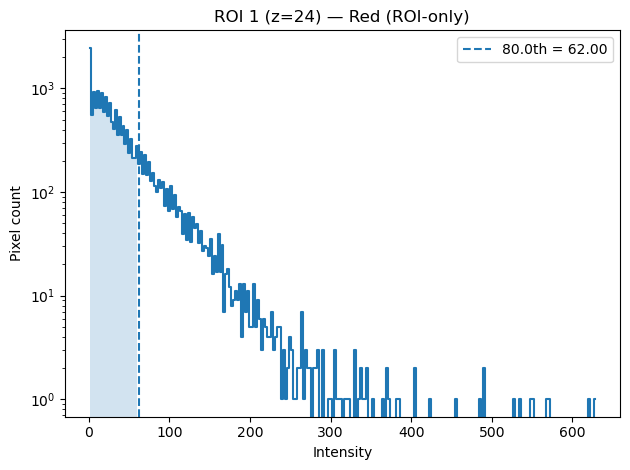

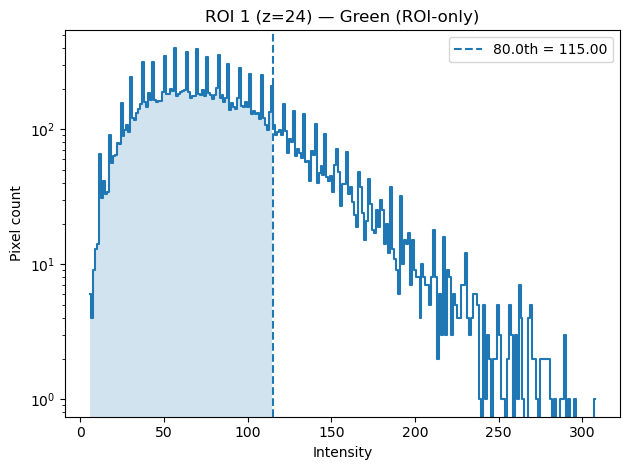

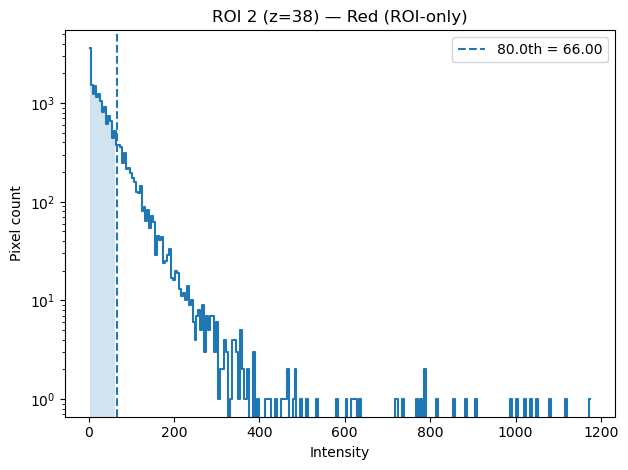

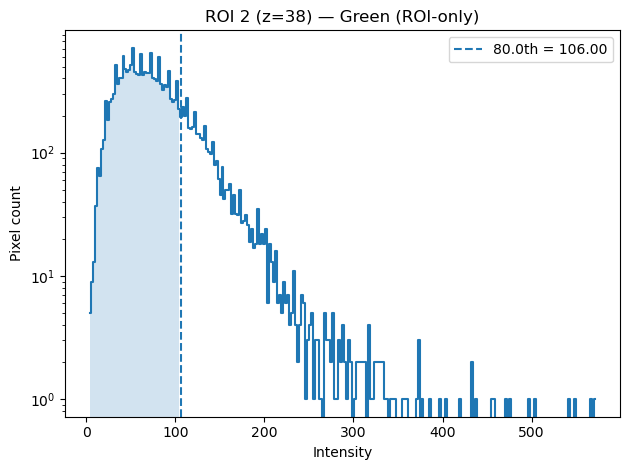

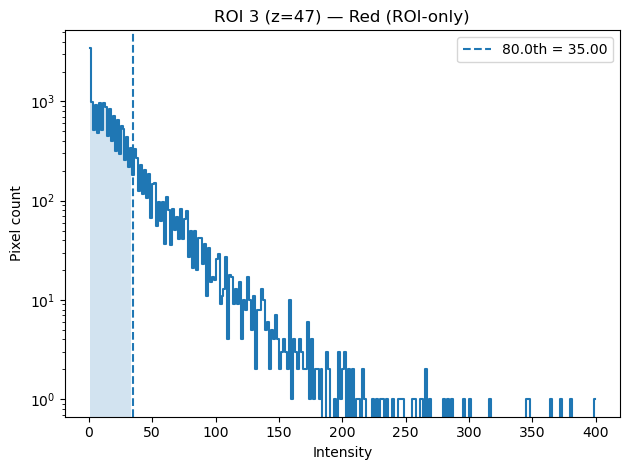

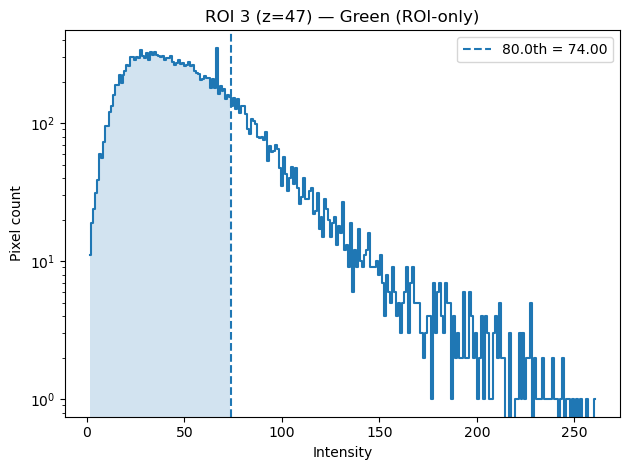

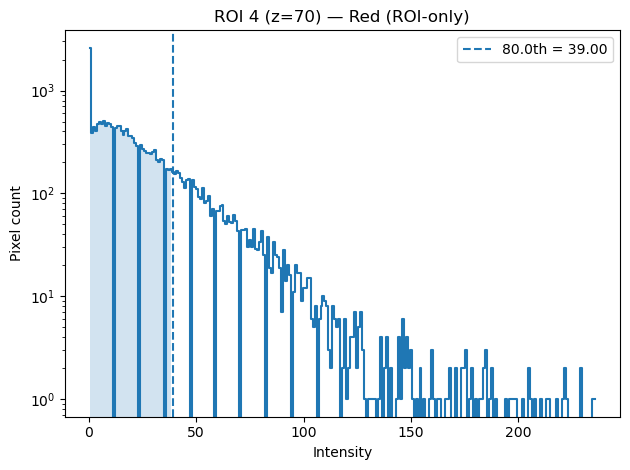

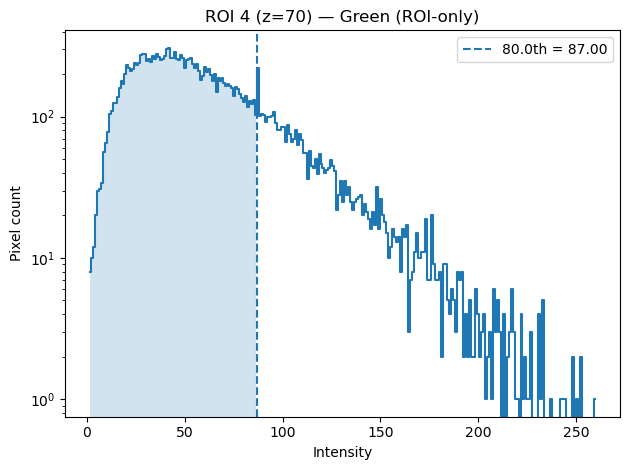

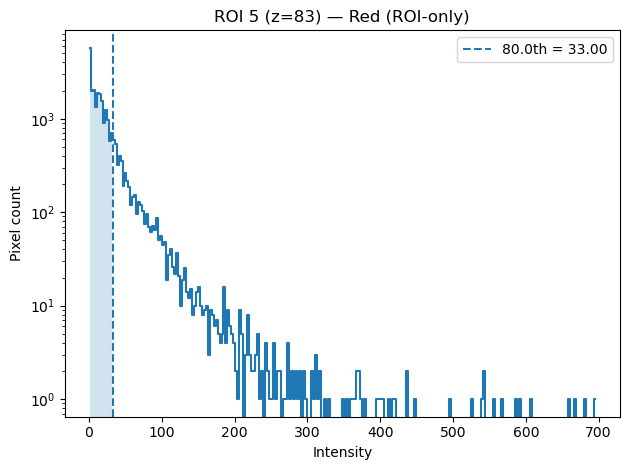

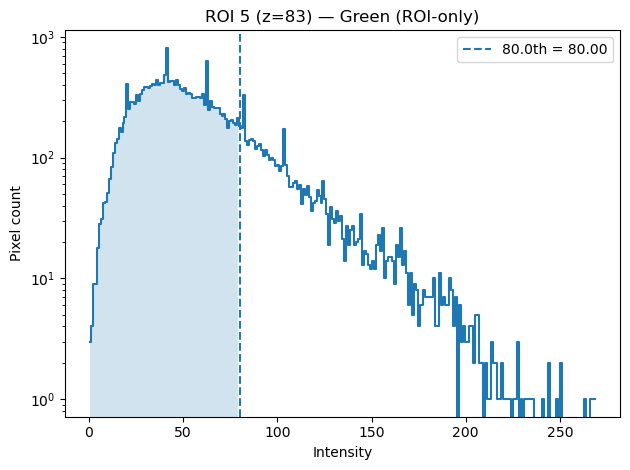

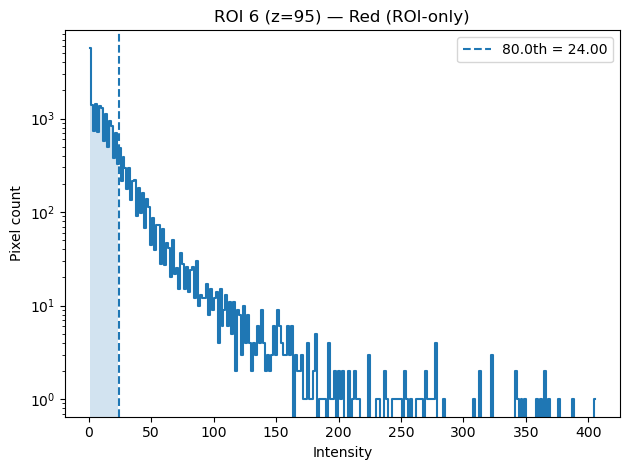

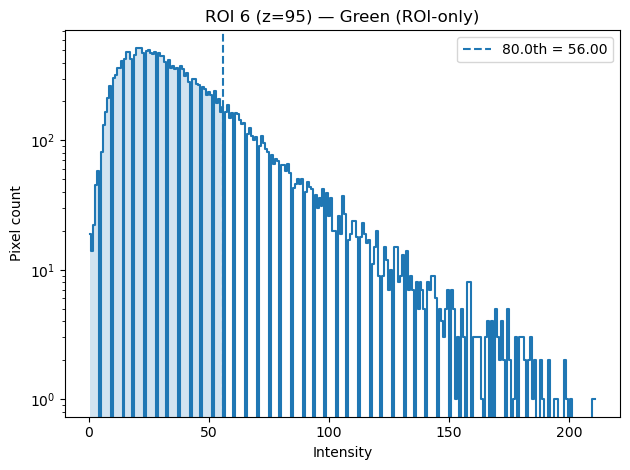

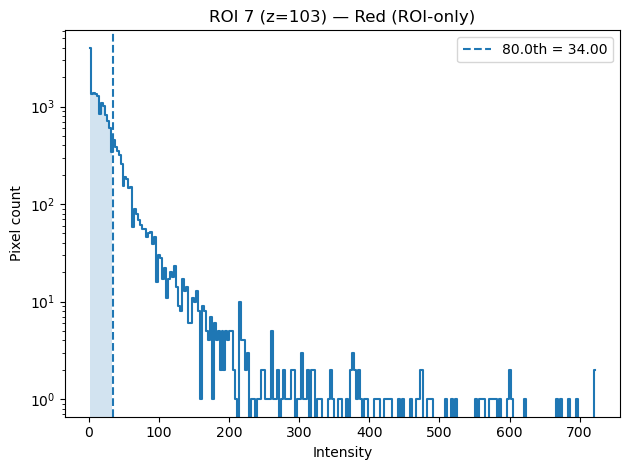

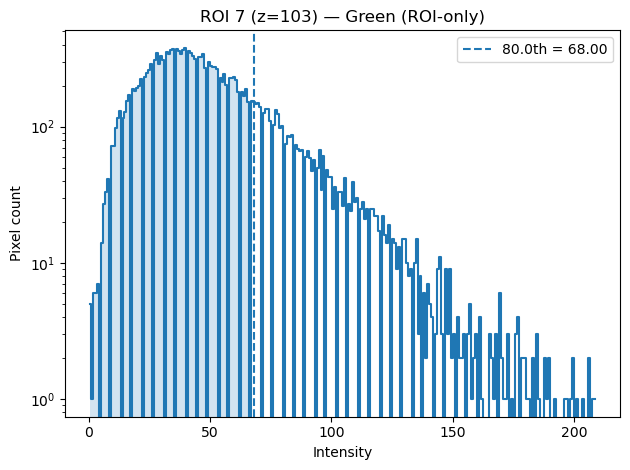

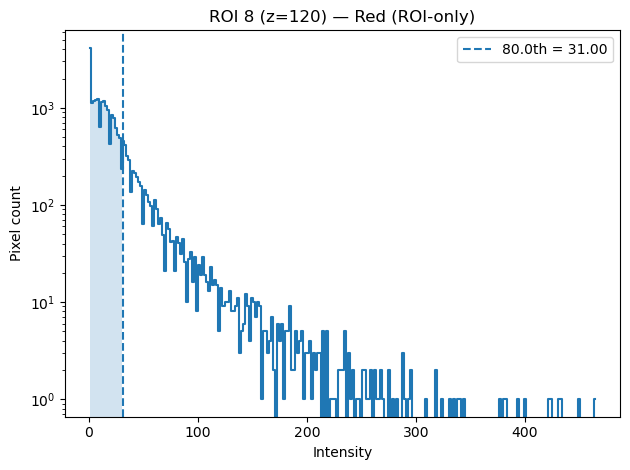

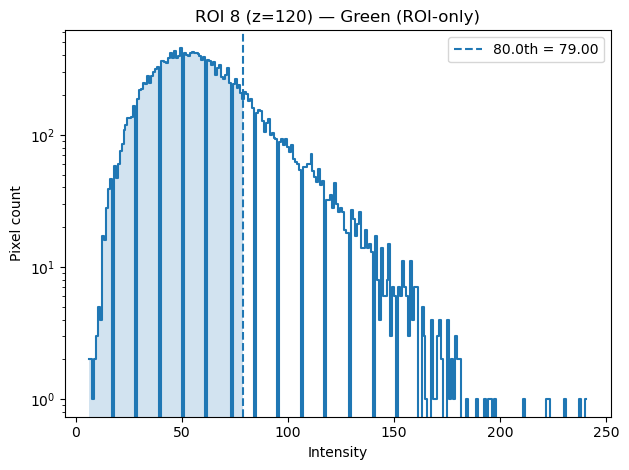

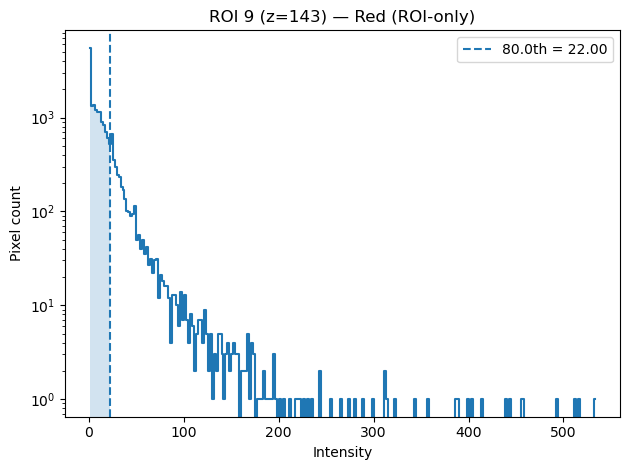

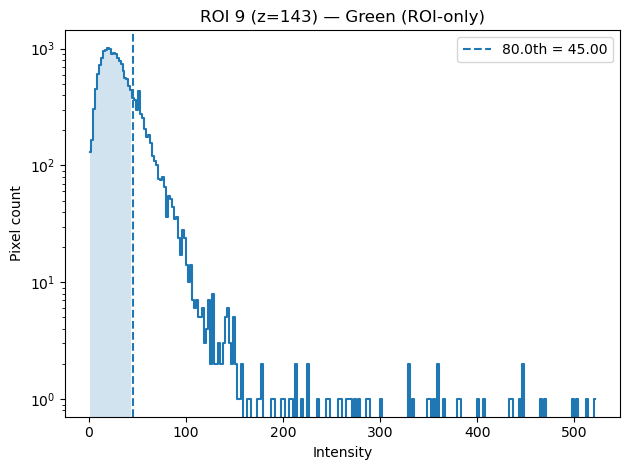

In [47]:
summary = plot_roi_histograms_per_slice(
    red_channel, green_channel, label_mask_checking,
    q=0.8, bins=256, exclude_zero=False, use_dtype_range=False,
    roi_ids=range(1, 10)
)

In [55]:
def plot_roi_histograms_per_slice(
    red_channel,
    green_channel,
    label_mask_checking,   # 3D labels: 0=bg, 1..n; each ROI painted on one Z slice (sparse pixels)
    q=0.05,                # percentile as fraction, e.g., 0.05 = 5%
    bins=512,              # histogram bins
    exclude_zero=False,    # ignore zeros inside the ROI
    use_dtype_range=False, # fix x-axis to full integer dtype (e.g., uint16 0..65535)
    roi_ids=None           # which ROIs to plot; None -> all positive labels
):
    # Ensure labels are (Z, Y, X)
    lbl = np.asarray(label_mask_checking)
    if lbl.ndim > 3:
        lbl = np.squeeze(lbl)
    if lbl.ndim != 3:
        raise ValueError(f"label_mask_checking must be 3D (Z,Y,X); got shape {lbl.shape}")
    if lbl.shape != red_channel.shape or lbl.shape != green_channel.shape:
        raise ValueError(f"shape mismatch: labels {lbl.shape}, red {red_channel.shape}, green {green_channel.shape}")

    n_max = int(lbl.max())
    if n_max < 1:
        raise ValueError("label_mask_checking has no positive labels.")
    if roi_ids is None:
        roi_ids = range(1, n_max + 1)
    else:
        roi_ids = [int(r) for r in roi_ids if 1 <= int(r) <= n_max]

    # Percentile helper (NumPy version compatible)
    def qtile(a, qf):
        a = np.asarray(a)
        a = a[np.isfinite(a)]
        if a.size == 0:
            return np.nan
        try:
            return float(np.quantile(a, qf, method="linear"))
        except TypeError:
            return float(np.quantile(a, qf, interpolation="linear"))

    # Histogram helper
    def make_hist(a, dtype, bins, use_dtype_range):
        if a.size == 0:
            # safe degenerate histogram
            return np.array([0]), np.array([0, 1]), np.array([0.5])
        if use_dtype_range and np.issubdtype(dtype, np.integer):
            lo, hi = 0, np.iinfo(dtype).max
        else:
            lo, hi = float(a.min()), float(a.max())
            if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
                lo, hi = 0.0, 1.0
        counts, edges = np.histogram(a, bins=bins, range=(lo, hi))
        centers = (edges[:-1] + edges[1:]) / 2.0
        return counts, edges, centers

    summary = {}
    rows = []  # for the summary DataFrame

    for i in roi_ids:
        # Find which Z slice this ROI was drawn on (expects exactly one Z; uses the first found)
        z_hits = np.where(lbl == i)[0]
        if z_hits.size == 0:
            print(f"ROI {i}: no painted pixels; skipping.")
            continue
        z_draw = int(z_hits[0])

        # 2D mask for ROI i on that exact slice (ONLY pixels inside the painted ROI)
        mask2d = (lbl[z_draw] == i)
        if not mask2d.any():
            print(f"ROI {i}: empty mask at z={z_draw}; skipping.")
            continue

        # STRICT ROI-only sampling via explicit coordinates
        y_ix, x_ix = np.where(mask2d)
        red_vals   = red_channel[z_draw,  y_ix, x_ix]
        green_vals = green_channel[z_draw, y_ix, x_ix]

        n_roi_px = int(mask2d.sum())
        n_red = int(red_vals.size)
        n_green = int(green_vals.size)

        if exclude_zero:
            red_vals_nz   = red_vals[red_vals != 0]
            green_vals_nz = green_vals[green_vals != 0]
        else:
            red_vals_nz, green_vals_nz = red_vals, green_vals

        # Percentiles & fractions for this ROI
        thr_red   = qtile(red_vals_nz, q)
        thr_green = qtile(green_vals_nz, q)
        frac_red   = float((red_vals_nz   <= thr_red).mean())   if red_vals_nz.size   else np.nan
        frac_green = float((green_vals_nz <= thr_green).mean()) if green_vals_nz.size else np.nan

        print(f"ROI {i} @ z={z_draw}")
        print(f"Red   {q*100:.1f}th pct = {thr_red:.6g} | fraction ≤ line: {frac_red*100:.2f}%")
        print(f"Green {q*100:.1f}th pct = {thr_green:.6g} | fraction ≤ line: {frac_green*100:.2f}%")

        # Histograms (ROI-only)
        cr, er, xr = make_hist(red_vals_nz,   red_channel.dtype,   bins, use_dtype_range)
        cg, eg, xg = make_hist(green_vals_nz, green_channel.dtype, bins, use_dtype_range)

        # Plots
        plt.figure()
        plt.plot(xr, cr, drawstyle="steps-mid")
        plt.axvline(thr_red, linestyle="--", linewidth=1.5,
                    label=f"{q*100:.1f}th = {thr_red:.2f}")
        plt.fill_between(xr, cr, where=xr <= thr_red, step="mid", alpha=0.2)
        plt.yscale("log")
        plt.xlabel("Intensity"); plt.ylabel("Pixel count")
        plt.title(f"ROI {i} (z={z_draw}) — Red (ROI-only)")
        plt.legend(); plt.tight_layout()

        plt.figure()
        plt.plot(xg, cg, drawstyle="steps-mid")
        plt.axvline(thr_green, linestyle="--", linewidth=1.5,
                    label=f"{q*100:.1f}th = {thr_green:.2f}")
        plt.fill_between(xg, cg, where=xg <= thr_green, step="mid", alpha=0.2)
        plt.yscale("log")
        plt.xlabel("Intensity"); plt.ylabel("Pixel count")
        plt.title(f"ROI {i} (z={z_draw}) — Green (ROI-only)")
        plt.legend(); plt.tight_layout()

        # stash per-ROI details
        summary[i] = {
            "z_draw": z_draw,
            "roi_pixels": n_roi_px,
            "red":   {"n": int(red_vals_nz.size),   "threshold": thr_red,   "fraction_leq": frac_red,
                      "counts": cr, "edges": er},
            "green": {"n": int(green_vals_nz.size), "threshold": thr_green, "fraction_leq": frac_green,
                      "counts": cg, "edges": eg},
        }

        rows.append({
            "ROI": i,
            "z": z_draw,
            "roi_pixels": n_roi_px,
            "red_threshold": float(thr_red) if np.isfinite(thr_red) else np.nan,
            "red_frac_leq_pct":  (np.round(frac_red  * 100.0, 1) if np.isfinite(frac_red)  else np.nan),
            "green_threshold": float(thr_green) if np.isfinite(thr_green) else np.nan,
            "green_frac_leq_pct": (np.round(frac_green * 100.0, 1) if np.isfinite(frac_green) else np.nan),
            "percentile_q": float(q),
        })

    # build a tidy summary DataFrame
    summary_df = pd.DataFrame(rows).set_index("ROI").sort_index()

    return summary, summary_df

ROI 1 @ z=24
Red   80.0th pct = 62 | fraction ≤ line: 80.29%
Green 80.0th pct = 115 | fraction ≤ line: 80.13%
ROI 2 @ z=38
Red   80.0th pct = 66 | fraction ≤ line: 80.44%
Green 80.0th pct = 106 | fraction ≤ line: 80.41%
ROI 3 @ z=47
Red   80.0th pct = 35 | fraction ≤ line: 80.37%
Green 80.0th pct = 74 | fraction ≤ line: 80.75%
ROI 4 @ z=70
Red   80.0th pct = 39 | fraction ≤ line: 80.02%
Green 80.0th pct = 87 | fraction ≤ line: 80.39%
ROI 5 @ z=83
Red   80.0th pct = 33 | fraction ≤ line: 80.60%
Green 80.0th pct = 80 | fraction ≤ line: 80.62%
ROI 6 @ z=95
Red   80.0th pct = 24 | fraction ≤ line: 80.86%
Green 80.0th pct = 56 | fraction ≤ line: 80.26%
ROI 7 @ z=103
Red   80.0th pct = 34 | fraction ≤ line: 80.34%
Green 80.0th pct = 68 | fraction ≤ line: 80.31%
ROI 8 @ z=120
Red   80.0th pct = 31 | fraction ≤ line: 80.14%
Green 80.0th pct = 79 | fraction ≤ line: 80.10%
ROI 9 @ z=143
Red   80.0th pct = 22 | fraction ≤ line: 81.13%
Green 80.0th pct = 45 | fraction ≤ line: 80.28%


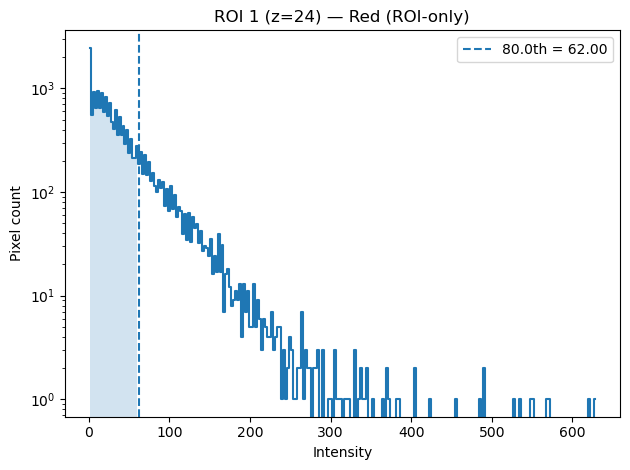

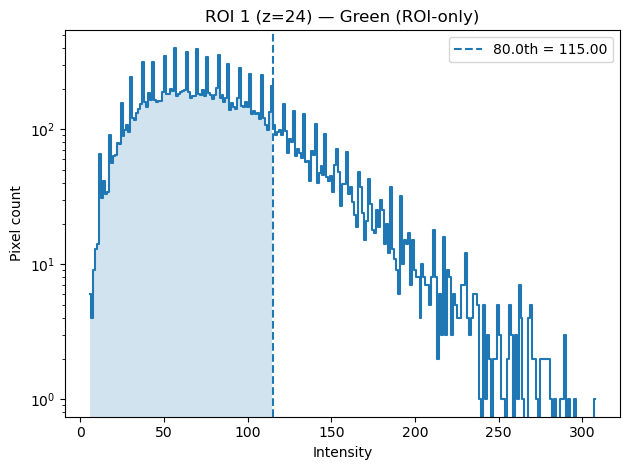

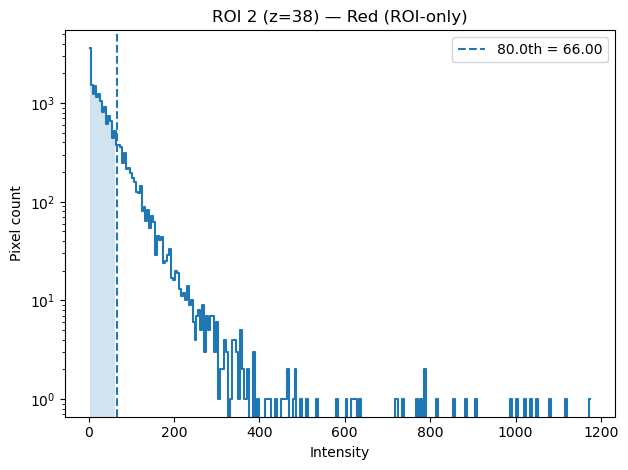

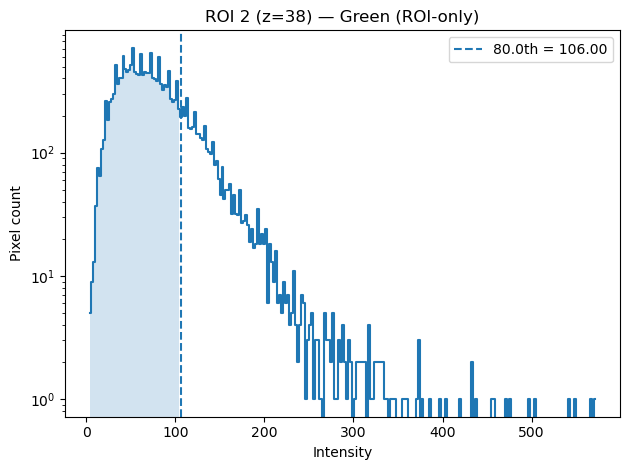

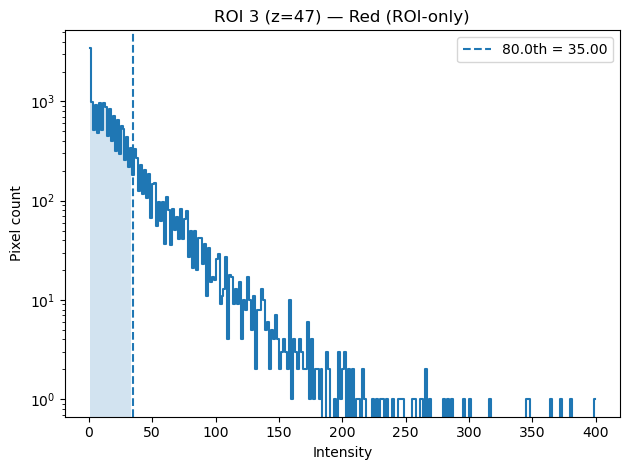

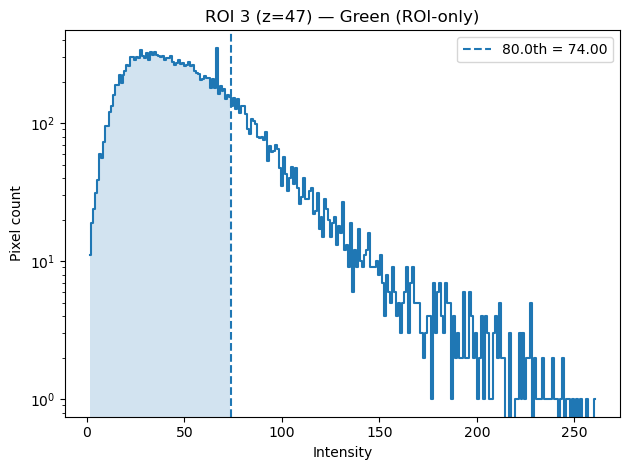

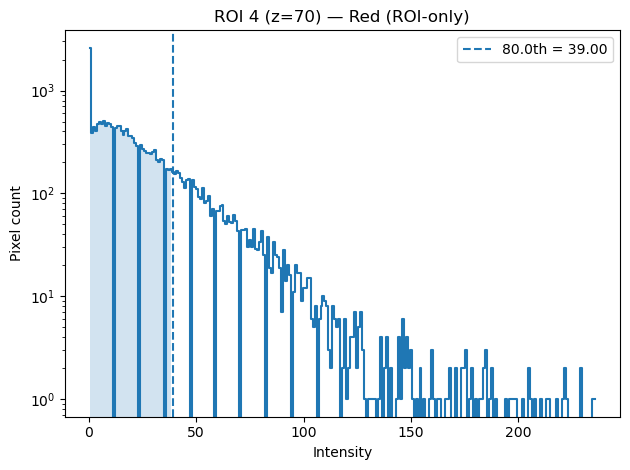

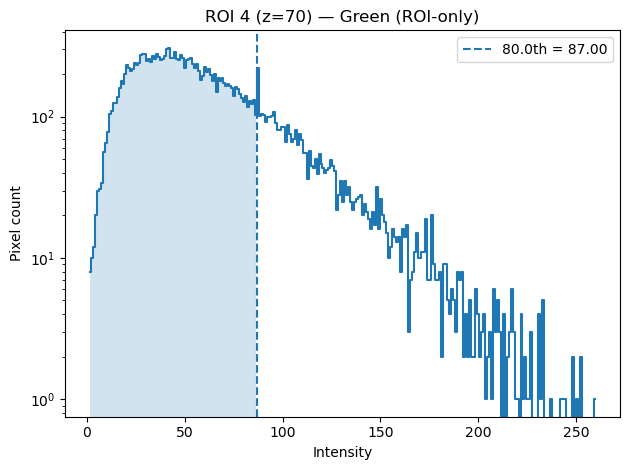

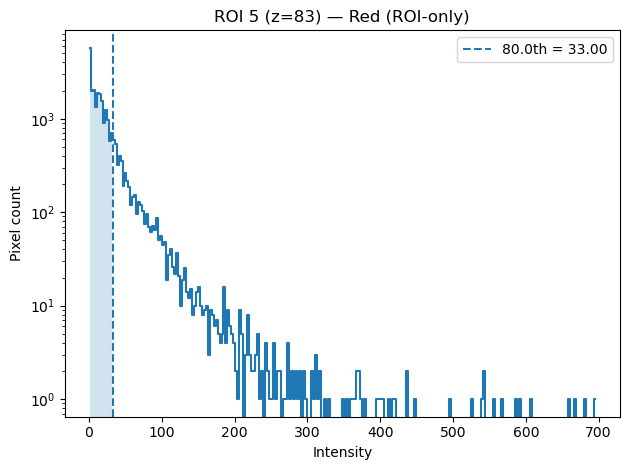

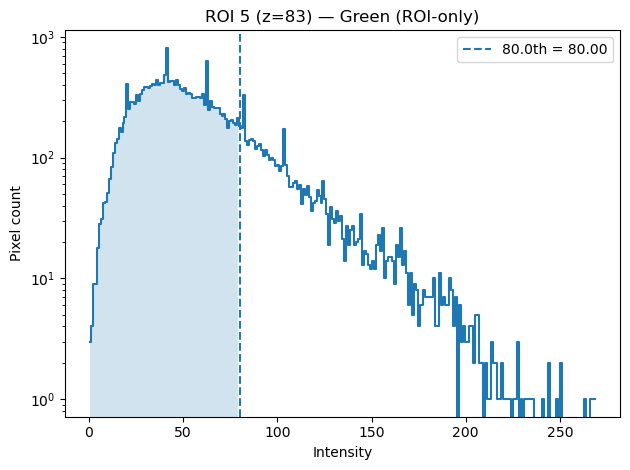

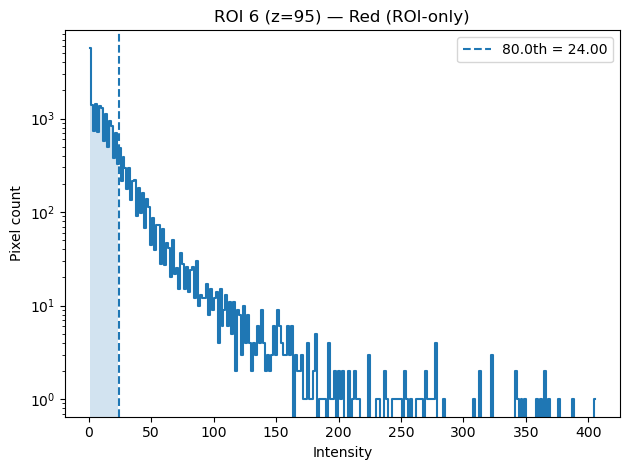

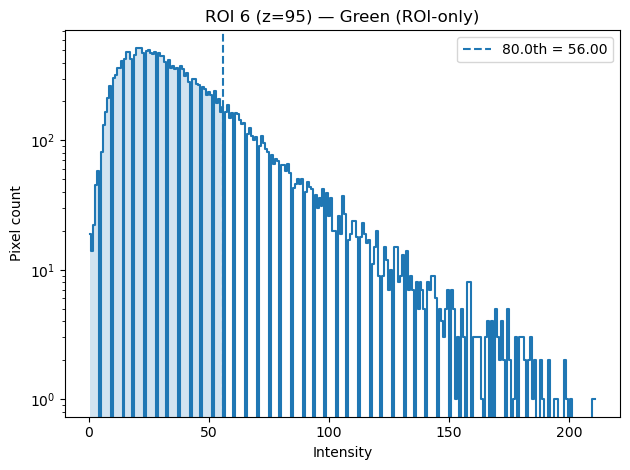

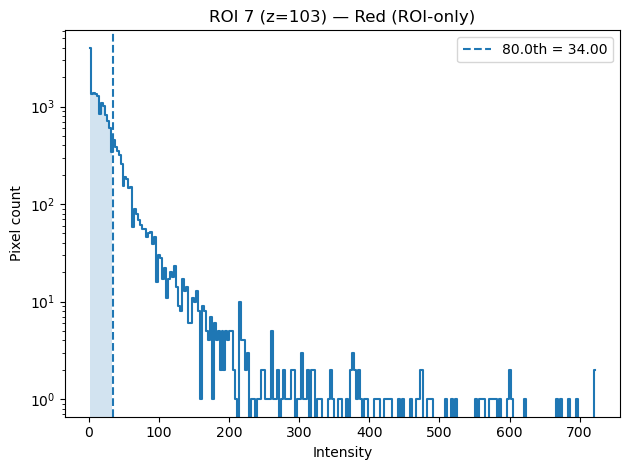

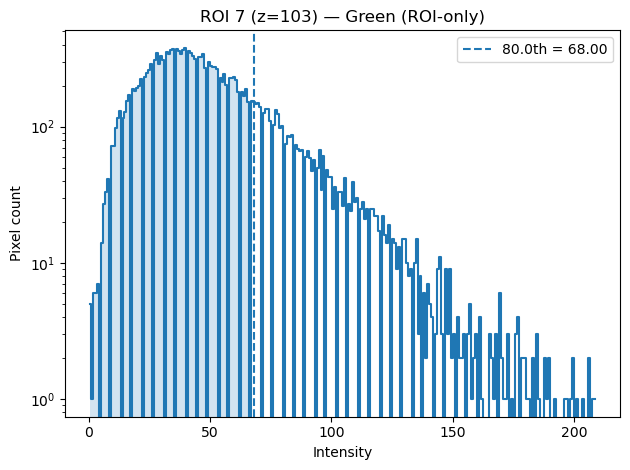

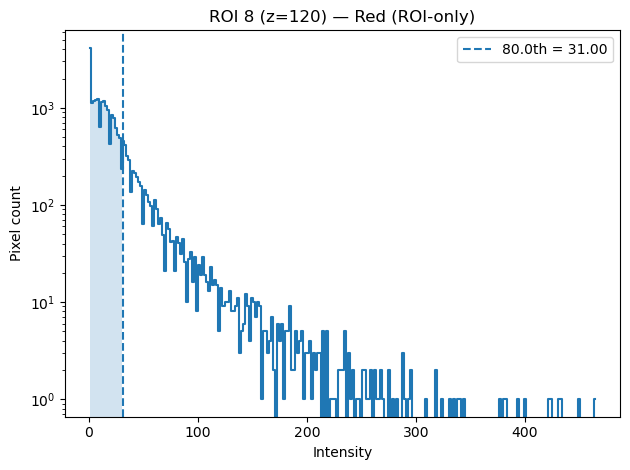

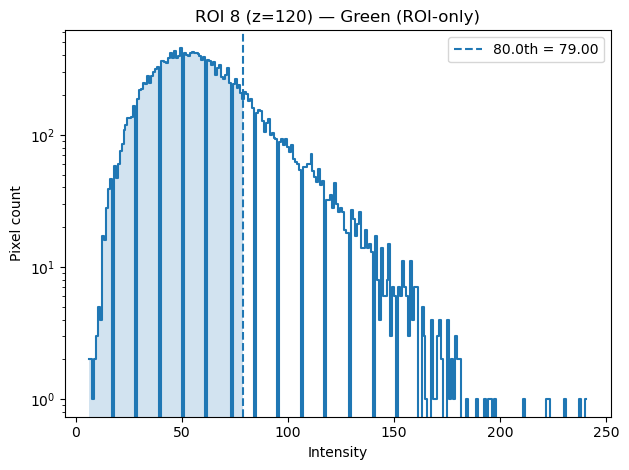

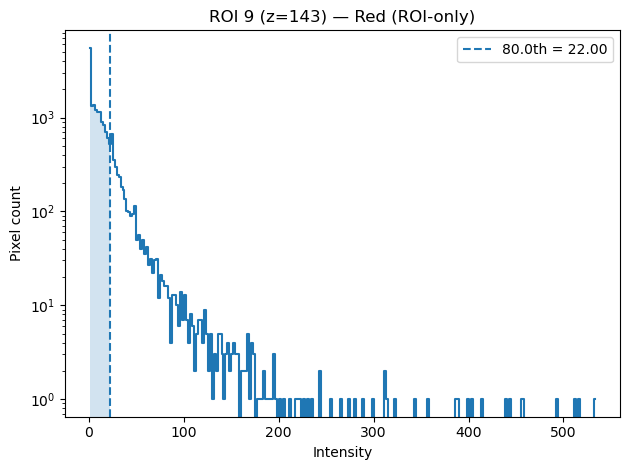

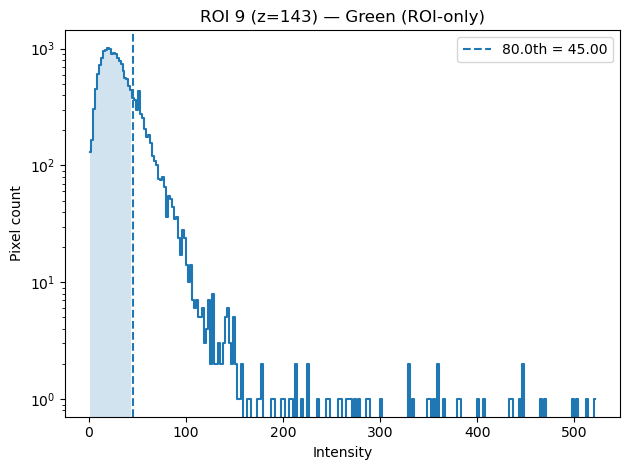

In [56]:
summary, summary_df = plot_roi_histograms_per_slice(
    red_channel, green_channel, label_mask_checking,
    q=0.80, bins=256, exclude_zero=False, use_dtype_range=False,
    roi_ids=range(1, 10)
)

In [57]:
summary_df

,z,roi_pixels,red_threshold,red_frac_leq_pct,green_threshold,green_frac_leq_pct,percentile_q
ROI,,,,,,,
1,24,18666,62.0,80.3,115.0,80.1,0.8
2,38,20027,66.0,80.4,106.0,80.4,0.8
3,47,19752,35.0,80.4,74.0,80.7,0.8
4,70,19770,39.0,80.0,87.0,80.4,0.8
5,83,25940,33.0,80.6,80.0,80.6,0.8
6,95,22611,24.0,80.9,56.0,80.3,0.8
7,103,18641,34.0,80.3,68.0,80.3,0.8
8,120,22394,31.0,80.1,79.0,80.1,0.8
9,143,18787,22.0,81.1,45.0,80.3,0.8


# opens the image and the masks together!

In [ ]:
# this cell opens the image and the masks together, so that i can check whether the thresholds i set are reasonable.

# --- sanity checks ---
Z, Y, X = red_channel.shape
assert green_channel.shape == (Z, Y, X)
assert label_mask.shape   == (Z, Y, X)
n_glom = int(label_mask.max())
assert len(z_ranges) == n_glom, f"Need one (z0, z1) per ROI (got {len(z_ranges)} for {n_glom})."

# --- outputs ---
mask_red_labels = np.zeros((Z, Y, X), dtype=np.int32)   # 0 = background; i = label i (colored by napari automatically)
mask_green_full = np.zeros((Z, Y, X), dtype=bool)       # binary (we'll show as green image)

for i in range(1, n_glom + 1):
    # find a painted slice for ROI i
    zs = np.where(label_mask == i)[0]
    if zs.size == 0:
        continue
    z_draw = zs[0]
    roi2d = (label_mask[z_draw] == i)                   # (Y, X) bool

    # z-range for this ROI
    z0, z1 = z_ranges[i - 1]
    zlen = z1 - z0 + 1

    # broadcast 2D ROI across its z-range
    roi_sub = np.repeat(roi2d[None, :, :], zlen, axis=0)   # (zlen, Y, X)

    # slice channels to that range
    red_sub   = red_channel[z0:z1+1]                    # (zlen, Y, X)
    green_sub = green_channel[z0:z1+1]                  # (zlen, Y, X)

    # thresholds: green subset ⊆ red
    mask_red_sub   = roi_sub & (red_sub   > red_threshold_lower)
    mask_green_sub = mask_red_sub & (green_sub > green_threshold_lower)

    # paint red-passing voxels with this ROI's integer ID (i) into the label volume
    z_rel, y_idx, x_idx = np.where(mask_red_sub)        # indices relative to z0
    mask_red_labels[z0 + z_rel, y_idx, x_idx] = i

    # accumulate green subset as binary
    mask_green_full[z0:z1+1] |= mask_green_sub

# --- visualize in napari ---
viewer = napari.Viewer()

# raw channels
viewer.add_image(red_channel,   name='Red (raw)',   colormap='red', contrast_limits=(0, 1000), blending='additive')
viewer.add_image(green_channel, name='Green (raw)', colormap='green', contrast_limits=(0, 1000),  blending='additive', visible=False)

# mask_red as LABELS → default napari per-label coloring (each ROI a different color)
viewer.add_labels(mask_red_labels, name='Mask – red per ROI', opacity=0.6)

# mask_green as IMAGE → solid green binary overlay
viewer.add_image(mask_green_full.astype(np.float32), name='Mask – green subset (binary)',
                 colormap='red', blending='additive', opacity=0.7, visible=False)

# optionally also show your original ROI labels
# viewer.add_labels(label_mask.astype(np.int32), name='ROI labels (drawn)', opacity=0.25)

napari.run()

In [80]:
# this cell works previously, when i only want to see what mask_red labels look like on top of the image. (no mask_green!!!)

# check the mask in napari
propagated_labels = np.zeros_like(label_mask, dtype=np.int32)  # shape (Z, Y, X)
# Your existing loop, with one extra line to “paint” into propagated_labels
for i in range(1, n_glom+1):
    # 1) find the slice you painted on:
    zs, ys, xs = np.where(label_mask == i)
    z_draw = zs[0]
    # 2) 2D ROI on drawn slice
    roi2d = (label_mask[z_draw] == i)
    # 3) Z‑range mask
    z0, z1 = z_ranges[i-1]
    Z, Y, X = label_mask.shape
    mask_z = (np.arange(Z) >= z0) & (np.arange(Z) <= z1)
    # 4) broadcast to 3D
    roi = mask_z[:, None, None] & roi2d[None, :, :]
    # 5) your threshold step and mean extraction
    red_sub   = red_channel[z0:z1+1]   * roi[z0:z1+1]
    mask_thr  = (red_sub > red_threshold_lower)
    # … compute mean_red[i-1], mean_green[i-1] as before …
    # — NEW: paint this ROI into your propagated label map —
    propagated_labels[roi & (red_channel > red_threshold_lower)] = i
# Save the new propagated label volume to TIFF
tf.imwrite('propagated_glom_labels.tif', propagated_labels.astype(np.uint16))
# Now open it in Napari alongside your images
viewer = napari.Viewer()
viewer.add_image(red_channel,   name='568 nm', colormap='red',   blending='additive')
viewer.add_image(green_channel, name='488 nm', colormap='green', blending='additive')
viewer.add_labels(propagated_labels, name='Propagated ROIs', opacity=0.6)
napari.run()



In [ ]:
# this cell definitely works, but failed to apply the green_threshold_lower...

n_glom    = int(label_mask.max())  # should be 18
mean_red   = np.zeros(n_glom, dtype=float)
mean_green = np.zeros(n_glom, dtype=float)
total_red   = np.zeros(n_glom, dtype=float)
total_green = np.zeros(n_glom, dtype=float)
for i in range(1, n_glom+1):
    # 1) find the slice you painted on:
    zs, ys, xs = np.where(label_mask == i)  # THIS COMMENT WILL SOLVE MANY POTENTIAL QUESTIONS: label_mask size is in this format: (Z, Y, X)
    z_draw = zs[0]                          # AICSImage makes the image format in this way! (i don't know why not in X->Y->Z). This makes z_draw the z layer that you draw labels on.
    # 2) extract the 2D ROI on that slice:
    roi2d = (label_mask[z_draw] == i)   # label_mask[z_draw] gives 2d array (Y, X): entries are the integer labels (background:0, ROIs:1-18)
                                        # label_mask[z_draw] == i: give each pixel True of False based on if it's has label 1. So now on this 2D sheet, only the pixels you draw (eg.) label 1 on has a T value.
    # 3) build a 1D mask for your Z‑range:
    z0, z1   = z_ranges[i-1]            # z0=a lowest z layer that the current label reaches, while z1=the highesr z laye the current label goes to.
    Z, Y, X  = label_mask.shape         # label_mask is the full X * full Y * full Z that your current image (eg. fly1) has.
    mask_z   = (np.arange(Z) >= z0) & (np.arange(Z) <= z1)  # np.arange(Z): generates the array [0, 1, 2, …, Z−1]
                                                            # np.arange(Z) >= z0: generates the array [False, F, ...T, T, ... F]
                                                            # () & (): generates the array with True only for indices between z0 and z1.
    # 4) make the final 3d mask:
    roi = mask_z[:, None, None] & roi2d[None, :, :]         # mask_z[:, None, None]: mask_z is originally 1d array, but using None it adds on dimension with length of 1
                                                                # so now it's a 3d array with the first dimension (or first element) length of z-stack range, the second and the third length of 1
                                                            # mask_z[:, None, None] size: (z-stack range, 1, 1)
                                                            # roi2d[None, :, :] size: (1, 1863, 1863) with some x and some y True.
                                                            # Then, the "&" step: for example:
                                                                    # mz goes from (3,1,1) → (3,2,2) by repeating the single 1×1 mask across the 2×2 grid in X and Y.
                                                                    # r2 goes from (1,2,2) → (3,2,2) by repeating the same 2×2 slice across the 3 Z‑layers.
                                                            # in this new 3d array: first dimension (element) is Z!
                                                            # so: in this new 3d array:
                                                                    # first look at mask_z, if it is true, that means there is label in this z-stack,
                                                                        # and thus i will allow the Y and X info from roi2d to get copied into this Z dimension.
                                                                    # if it's False, then there is no label on this z-stack,
                                                                        # so i won't allow roi2d to copy anything to here, and this whole Z dimension will have all False values
            # for example: mask_z = np.array([ True, False,  True ]), roi2d  = np.array([[ True, False], [False,  True]]),
                # then roi = array([[[ True, False], [False,  True]],   # z=0 slice uses roi2d because mask_z[0] is True
                #                   [[False, False], [False, False]],   # z=1 slice is all False because mask_z[1] is False
                #                   [[ True, False], [False,  True]]])  # z=2 slice repeats roi2d because mask_z[2] is True.
    # — b) zero out outside your propagated ROI —
    red_sub   = red_channel[z0:z1+1]   * roi[z0:z1+1]      # red_channel[z0:z1+1]: takes only the z-stacks from the original image (red channel only) that are within the current label z-stack range
                                                           # roi[z0:z1+1]: only slicing in the first (Z) dimension!
                                                           # after multiplication: it's a smaller Z * 1863 * 1863 3d array, with the in-label pixels having value of 1*it's original value (because roi[z0:z1+1] has T or F entries, so multiplying a T=*1 while multiplying a F=*0)
    green_sub = green_channel[z0:z1+1]                     # only select out the correct z stacks, haven't picked the inner pixels yet!
    # — c) threshold & extract means —
    mask      = (red_sub > red_threshold_lower)            # after making the correct label in each z stack, "mask" is the mask for correct pixels.
    red_vals   = red_sub  [mask]                           # only extract the value from the pixel in "mask"
    green_vals = green_sub[mask]
    mean_red[i-1]   = red_vals.mean()   if red_vals.size   else np.nan
    mean_green[i-1] = green_vals.mean() if green_vals.size else np.nan
    total_red[i-1]   = red_vals.sum()   if red_vals.size   else np.nan
    total_green[i-1] = green_vals.sum() if green_vals.size else np.nan


In [ ]:
# don't know why i have this cell...but i will just keep it here...



props_green = regionprops_table(
    label_mask, 
    intensity_image=green_channel,
    properties=('label', 'area', 'mean_intensity', 'max_intensity', 'min_intensity')
)
df_green = pd.DataFrame(props_green)
# Rename columns to indicate green measurements
df_green = df_green.rename(columns={
    'label': 'label',
    'area': 'area',
    'mean_intensity': 'green_mean_intensity',
    'max_intensity': 'green_max_intensity',
    'min_intensity': 'green_min_intensity'
})

props_red = regionprops_table(
    label_mask, 
    intensity_image=red_channel,
    properties=('mean_intensity', 'max_intensity', 'min_intensity')
)
df_red = pd.DataFrame(props_red)
# Rename columns to indicate red measurements
df_red = df_red.rename(columns={
    'mean_intensity': 'red_mean_intensity',
    'max_intensity': 'red_max_intensity',
    'min_intensity': 'red_min_intensity'
})

df_combined = pd.concat([df_green, df_red], axis=1)
df_combined

,label,area,green_mean_intensity,green_max_intensity,green_min_intensity,red_mean_intensity,red_max_intensity,red_min_intensity
0,1,25892.0,26.886258,150.0,3.0,89.018925,1286.0,0.0
1,2,30601.0,34.594000,427.0,4.0,228.817816,7016.0,0.0
2,3,38668.0,46.797352,504.0,7.0,314.064498,6968.0,0.0
3,4,34910.0,41.592237,304.0,5.0,257.410771,7312.0,0.0
4,5,42942.0,50.595547,1168.0,4.0,241.474454,6336.0,0.0
5,6,39097.0,47.902371,402.0,5.0,218.569225,9609.0,0.0
6,7,42310.0,93.945805,960.0,7.0,1647.427393,13304.0,0.0
7,8,47045.0,35.267829,329.0,5.0,123.847316,3310.0,0.0
8,9,36320.0,26.517098,259.0,2.0,55.211151,1109.0,0.0
9,10,34457.0,35.726442,156.0,2.0,82.081261,1029.0,0.0
